# Notebook 02 — Gemelo Digital y Generación de Dataset Sintético

**TFG:** Detección de Anomalías de Consumo Eléctrico en Edge Computing para la Mitigación de Ataques FDI

---

## Arquitectura General

```
  DATOS REALES (train)                   GEMELO DIGITAL
  ──────────────────                     ────────────────
  Perfiles horarios ──→ fit() ──→ μ(h,d,m) + σ(h,d,m)
  Correlaciones ─────────────→ L (Cholesky cov)
  Relación P=V·I ─────────────→ cos(φ) estimado

  VALIDACIÓN (vs. test real)
  ──────────────────────────
  Distribuciones  ─→ KS test / histograma
  Perfiles        ─→ Pearson (hourly / monthly)
  Correlaciones   ─→ Frobenius ∥C_real − C_syn∥
  Autocorrelación ─→ ACF(lag 1-168h)
  OBJETIVO: score compuesto ≥ 0.95

  GENERACIÓN SINTÉTICA (10 años)
  ──────────────────────────────
  Dec 2010 → Dec 2020 (frecuencia 1 min)
  Deriva anual: +2 %/año ± ruido inter-anual

  INYECCIÓN DE 15 TIPOS DE ATAQUES FDI
  ─────────────────────────────────────
  Básicos (3): scaling, offset, noise
  Temporales (4): ramp, pulse, step, intermittent
  Patrón (4): replay, weekend_mimicry, seasonal_swap, smooth_decay
  Capa física (4): correlated_scaling, voltage_spoof, load_shift, adversarial
```

## 0. Setup

In [42]:
!pip install statsmodels --quiet

17152.67s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, time, os, json, warnings
from scipy.stats import ks_2samp, pearsonr
from statsmodels.tsa.stattools import acf as compute_acf

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'

FEATURE_COLS = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

print('Setup completo')

Setup completo


## 1. Carga de Datos Reales

Usamos `clean_full.csv` (datos originales sin modificar) como fuente de verdad.  
El gemelo se **ajusta sobre train** y se **valida sobre test** — exactamente como los modelos de ML.

In [44]:
df_full = pd.read_csv(
    BASE_DIR + 'clean_full.csv',
    index_col='datetime', parse_dates=True,
    usecols=['datetime'] + FEATURE_COLS
)

CUTOFF       = pd.Timestamp('2009-09-20 12:45:00')
df_train     = df_full[df_full.index <  CUTOFF][FEATURE_COLS].dropna()
df_test_real = df_full[df_full.index >= CUTOFF][FEATURE_COLS].dropna()

print(f'Train:     {len(df_train):,} filas | {df_train.index.min().date()} → {df_train.index.max().date()}')
print(f'Test real: {len(df_test_real):,} filas | {df_test_real.index.min().date()} → {df_test_real.index.max().date()}')
print()
print('Estadisticas del train (GAP):')
print(df_train['Global_active_power'].describe().round(4))

Train:     1,444,513 filas | 2006-12-16 → 2009-09-20
Test real: 604,999 filas | 2009-09-20 → 2010-11-26

Estadisticas del train (GAP):
count    1.444513e+06
mean     1.086500e+00
std      1.090600e+00
min      7.600000e-02
25%      2.960000e-01
50%      5.480000e-01
75%      1.520000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64


## 2. Gemelo Digital

### Modelo estadístico

Para un timestamp $t$ con (hora $h$, día_semana $d$, mes $m$):

$$\mathbf{y}(t) = \boldsymbol{\mu}(h,d,m) + \boldsymbol{\sigma}(h,d,m) \odot \mathbf{L}\,\boldsymbol{\varepsilon}(t)$$

- $\boldsymbol{\mu}(h,d,m)$: perfil medio por combinación hora × día × mes
- $\boldsymbol{\sigma}(h,d,m)$: desviación estándar condicional
- $\mathbf{L}$: descomposición de Cholesky de la covarianza de residuos normalizados → preserva correlaciones entre features
- $\boldsymbol{\varepsilon}(t) \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$

### Restricción física

$P = V \times I \times \cos(\varphi) / 1000$ → se estima $\cos(\varphi)$ del train y se recomputa $I$ tras la generación.

In [45]:
class DigitalTwin:
    '''
    Gemelo Digital de consumo electrico domestico.
    Modelo: y(t) = mu(h,d,m) + sigma(h,d,m) * L * eps(t)
    '''

    # Rangos fisicamente validos para cada feature
    CLIP = {
        'Global_active_power':   (0.076, 15.0),
        'Global_reactive_power': (0.0,   1.5),
        'Voltage':               (220.0, 260.0),
        'Global_intensity':      (0.2,   50.0),
        'Sub_metering_1':        (0.0,   90.0),
        'Sub_metering_2':        (0.0,   85.0),
        'Sub_metering_3':        (0.0,   32.0),
    }

    def __init__(self, feature_cols):
        self.feature_cols  = list(feature_cols)
        self.profiles_mean = {}
        self.profiles_std  = {}
        self.L_chol        = None
        self.power_factor  = None
        self.fitted        = False

    def fit(self, df):
        df = df.copy()
        df['_h'] = df.index.hour
        df['_d'] = df.index.dayofweek
        df['_m'] = df.index.month

        # 1. Perfiles estadisticos por (hora, dia_semana, mes)
        for feat in self.feature_cols:
            grp = df.groupby(['_h', '_d', '_m'])[feat]
            self.profiles_mean[feat] = grp.mean()
            std_s = grp.std()
            fallback_std = max(df[feat].std() * 0.1, 1e-4)
            self.profiles_std[feat] = std_s.fillna(fallback_std)

        # 2. Residuos normalizados para la covarianza entre features
        n      = len(df)
        resid  = np.zeros((n, len(self.feature_cols)))
        idx_mi = pd.MultiIndex.from_arrays([df['_h'], df['_d'], df['_m']])

        for j, feat in enumerate(self.feature_cols):
            mu_arr  = self.profiles_mean[feat].reindex(idx_mi).values
            std_arr = self.profiles_std[feat].reindex(idx_mi).values
            mu_arr  = np.where(np.isnan(mu_arr),  df[feat].mean(),          mu_arr)
            std_arr = np.where(np.isnan(std_arr), df[feat].std() * 0.1 + 1e-4, std_arr)
            resid[:, j] = (df[feat].values - mu_arr) / (std_arr + 1e-8)

        # 3. Covarianza y descomposicion de Cholesky
        cov = np.cov(resid.T) + np.eye(len(self.feature_cols)) * 1e-5
        try:
            self.L_chol = np.linalg.cholesky(cov)
        except np.linalg.LinAlgError:
            # Fallback: solo diagonal (independencia)
            self.L_chol = np.diag(np.sqrt(np.maximum(np.diag(cov), 1e-8)))

        # 4. Factor de potencia: cos(phi) = P / (V*I/1000)
        pf = (df['Global_active_power'] /
              (df['Voltage'] * df['Global_intensity'] / 1000.0 + 1e-8))
        self.power_factor = float(
            pf.replace([np.inf, -np.inf], np.nan).dropna().clip(0.5, 1.0).median()
        )

        self.fitted = True
        n_groups = len(self.profiles_mean['Global_active_power'])
        print(f'DigitalTwin ajustado | {n:,} muestras | {n_groups} grupos de perfil')
        print(f'Factor de potencia cos(phi) = {self.power_factor:.4f}')
        return self

    def generate(self, timestamps, seed=None, year_drift=0.0):
        '''
        Genera datos sinteticos para los timestamps dados.
        year_drift: fraccion de incremento anual del consumo (e.g. 0.02 = +2%/ano).
        '''
        assert self.fitted, 'Llama a fit() primero'
        if seed is not None:
            np.random.seed(seed)

        n      = len(timestamps)
        h, d, m = timestamps.hour, timestamps.dayofweek, timestamps.month
        idx_mi = pd.MultiIndex.from_arrays([h, d, m])

        # Ruido gaussiano correlacionado entre features
        eps        = np.random.randn(len(self.feature_cols), n)
        corr_noise = (self.L_chol @ eps).T   # (n, n_features)

        data = {}
        for j, feat in enumerate(self.feature_cols):
            mu  = self.profiles_mean[feat].reindex(idx_mi).values
            std = self.profiles_std[feat].reindex(idx_mi).values
            mu  = np.where(np.isnan(mu),  self.profiles_mean[feat].mean(), mu)
            std = np.where(np.isnan(std), self.profiles_std[feat].mean(),  std)
            vals = mu + std * corr_noise[:, j]

            # Deriva de consumo inter-anual (solo potencia activa)
            if year_drift != 0.0 and feat == 'Global_active_power':
                vals = vals * (1.0 + year_drift)

            lo, hi = self.CLIP.get(feat, (-np.inf, np.inf))
            data[feat] = np.clip(vals, lo, hi)

        df_syn = pd.DataFrame(data, index=timestamps)

        # Recomputa Global_intensity desde la fisica: I = P*1000 / (V * cos(phi))
        df_syn['Global_intensity'] = (
            df_syn['Global_active_power'] * 1000.0
            / (df_syn['Voltage'] * self.power_factor + 1e-8)
        ).clip(0.2, 50.0)

        return df_syn


print('Clase DigitalTwin definida')

Clase DigitalTwin definida


In [46]:
twin = DigitalTwin(FEATURE_COLS)
twin.fit(df_train)

# Guardar modelo
joblib.dump(twin, BASE_DIR + 'digital_twin_model.pkl')
print('Modelo guardado: digital_twin_model.pkl')

DigitalTwin ajustado | 1,444,513 muestras | 2016 grupos de perfil
Factor de potencia cos(phi) = 0.9903
Modelo guardado: digital_twin_model.pkl


## 3. Generación Sintética del Periodo de Test

In [47]:
print('Generando datos sinteticos para el periodo de test...')
t0 = time.time()
df_syn_test = twin.generate(df_test_real.index, seed=42)
t_gen = time.time() - t0

print(f'Generados {len(df_syn_test):,} filas en {t_gen:.1f} s')
print()
print('Comparativa estadistica (GAP):')
print(f'  Real      — media {df_test_real["Global_active_power"].mean():.4f}  std {df_test_real["Global_active_power"].std():.4f}')
print(f'  Sintetico — media {df_syn_test["Global_active_power"].mean():.4f}  std {df_syn_test["Global_active_power"].std():.4f}')

Generando datos sinteticos para el periodo de test...
Generados 604,999 filas en 0.2 s

Comparativa estadistica (GAP):
  Real      — media 1.1038  std 0.9732
  Sintetico — media 1.1690  std 1.0337


## 4. Validación de Similitud (objetivo ≥ 0.95)

### Métricas

| Componente | Métrica | Descripción |
|-----------|---------|-------------|
| Distribuciones | 1 − KS_stat (promedio features) | Similaridad distribucional por feature |
| Perfiles | Pearson(r_hourly, r_monthly) | Correlación de perfiles medios |
| Correlaciones | 1 − ∥C_real − C_syn∥_F / n_features | Preservación de correlaciones entre features |
| Autocorrelación | Pearson(ACF_real, ACF_syn) lag 1−168h | Estructura temporal |

Score compuesto = media ponderada de las 4 componentes.

In [48]:
def hist_overlap(real, syn, bins=200):
    '''Coeficiente de Bhattacharyya entre dos distribuciones (1D).'''
    lo = min(real.min(), syn.min())
    hi = max(real.max(), syn.max())
    edges = np.linspace(lo, hi, bins + 1)
    h_r, _ = np.histogram(real, bins=edges, density=True)
    h_s, _ = np.histogram(syn,  bins=edges, density=True)
    h_r = h_r / (h_r.sum() + 1e-10)
    h_s = h_s / (h_s.sum() + 1e-10)
    return float(np.sum(np.sqrt(h_r * h_s)))


def similarity_score(df_real, df_syn, feat_cols, verbose=True):
    '''Calcula el score de similitud compuesto entre datos reales y sinteticos.'''
    scores = {}
    N_SAMPLE = 50_000

    # 1. Distribucion (histograma Bhattacharyya)
    dist_sims = []
    for feat in feat_cols:
        r = df_real[feat].dropna().values
        s = df_syn[feat].dropna().values
        if len(r) > N_SAMPLE:
            r = np.random.choice(r, N_SAMPLE, replace=False)
        if len(s) > N_SAMPLE:
            s = np.random.choice(s, N_SAMPLE, replace=False)
        dist_sims.append(hist_overlap(r, s))
    scores['distribution'] = np.mean(dist_sims)

    # 2. Perfiles (media horaria y mensual del GAP)
    real_h  = df_real.copy()
    syn_h   = df_syn.copy()
    real_h['hour']  = real_h.index.hour
    syn_h['hour']   = syn_h.index.hour
    real_h['month'] = real_h.index.month
    syn_h['month']  = syn_h.index.month

    rp_h = real_h.groupby('hour')['Global_active_power'].mean()
    sp_h = syn_h.groupby('hour')['Global_active_power'].mean()
    r_h  = pearsonr(rp_h.values, sp_h.reindex(rp_h.index).fillna(sp_h.mean()).values)[0]

    rp_m = real_h.groupby('month')['Global_active_power'].mean()
    sp_m = syn_h.groupby('month')['Global_active_power'].mean()
    r_m  = pearsonr(rp_m.values, sp_m.reindex(rp_m.index).fillna(sp_m.mean()).values)[0]

    scores['profile'] = float((r_h + r_m) / 2)

    # 3. Correlacion entre features
    C_r = df_real[feat_cols].corr().values
    C_s = df_syn[feat_cols].corr().values
    n_f = len(feat_cols)
    frob_dist = np.linalg.norm(C_r - C_s, 'fro')
    scores['correlation'] = max(0.0, 1.0 - frob_dist / (2 * n_f))

    # 4. ACF similarity (datos horarios, lag 1-168h)
    real_h_ser = df_real['Global_active_power'].resample('h').mean().dropna()
    syn_h_ser  = df_syn['Global_active_power'].resample('h').mean().dropna()
    min_len = min(len(real_h_ser), len(syn_h_ser), 2000)
    acf_r = compute_acf(real_h_ser.values[:min_len], nlags=168, fft=True)
    acf_s = compute_acf(syn_h_ser.values[:min_len],  nlags=168, fft=True)
    scores['acf'] = max(0.0, float(pearsonr(acf_r, acf_s)[0]))

    # Compuesto
    scores['composite'] = float(np.mean([scores['distribution'],
                                          scores['profile'],
                                          scores['correlation'],
                                          scores['acf']]))
    if verbose:
        print('='*50)
        print('SCORE DE SIMILITUD GEMELO DIGITAL vs REAL')
        print('='*50)
        for k, v in scores.items():
            status = '✓' if v >= 0.95 else ('~' if v >= 0.90 else '✗')
            print(f'  {status} {k:15s}: {v:.4f} ({v*100:.1f}%)')
        print()
        if scores['composite'] >= 0.95:
            print(f'  → OBJETIVO CUMPLIDO: {scores["composite"]*100:.1f}% >= 95%')
        else:
            print(f'  → Objetivo 95% no alcanzado aun ({scores["composite"]*100:.1f}%)')
            print(f'    Considera aumentar el numero de grupos de perfil o ajustar el modelo.')
    return scores


scores_test = similarity_score(df_test_real, df_syn_test, FEATURE_COLS)

SCORE DE SIMILITUD GEMELO DIGITAL vs REAL
  ✗ distribution   : 0.8132 (81.3%)
  ✓ profile        : 0.9768 (97.7%)
  ✓ correlation    : 0.9740 (97.4%)
  ✓ acf            : 0.9834 (98.3%)
  ~ composite      : 0.9368 (93.7%)

  → Objetivo 95% no alcanzado aun (93.7%)
    Considera aumentar el numero de grupos de perfil o ajustar el modelo.


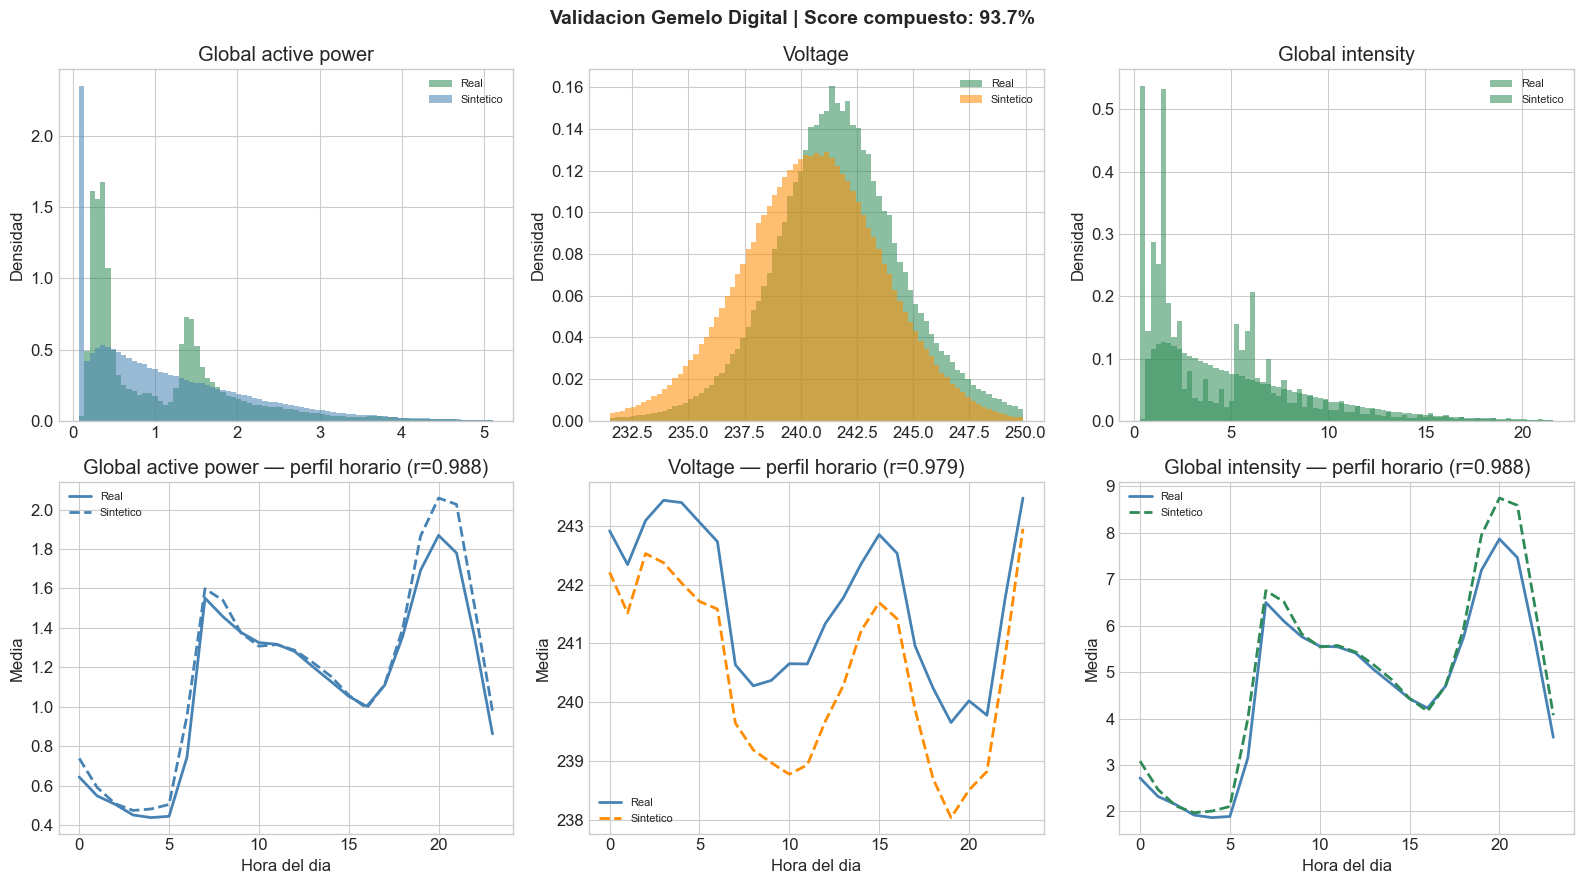

In [49]:
# Visualizacion de la validacion
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
feat_colors = ['steelblue', 'seagreen', 'darkorange', 'crimson', 'purple', 'teal', 'brown']

# Fila 1: distribuciones de GAP, Voltage, Global_intensity
for ax, feat, color in zip(axes[0], ['Global_active_power', 'Voltage', 'Global_intensity'],
                            ['steelblue', 'darkorange', 'seagreen']):
    r = df_test_real[feat].dropna().values
    s = df_syn_test[feat].dropna().values
    lo = min(np.percentile(r, 0.5), np.percentile(s, 0.5))
    hi = max(np.percentile(r, 99.5), np.percentile(s, 99.5))
    bins = np.linspace(lo, hi, 80)
    ax.hist(r, bins=bins, alpha=0.55, color='seagreen', label='Real',     density=True)
    ax.hist(s, bins=bins, alpha=0.55, color=color,       label='Sintetico', density=True)
    ax.set(title=feat.replace('_', ' '), ylabel='Densidad')
    ax.legend(fontsize=8)

# Fila 2: perfiles horarios (GAP, Voltage, GI)
for ax, feat, color in zip(axes[1], ['Global_active_power', 'Voltage', 'Global_intensity'],
                            ['steelblue', 'darkorange', 'seagreen']):
    rp = df_test_real.copy()
    sp = df_syn_test.copy()
    rp['h'] = rp.index.hour
    sp['h'] = sp.index.hour
    rp_m = rp.groupby('h')[feat].mean()
    sp_m = sp.groupby('h')[feat].mean()
    ax.plot(rp_m.index, rp_m.values,  'steelblue', lw=2,  label='Real')
    ax.plot(sp_m.index, sp_m.values,  color,       lw=2,  linestyle='--', label='Sintetico')
    r, _ = pearsonr(rp_m.values, sp_m.values)
    ax.set(title=f'{feat.replace("_"," ")} — perfil horario (r={r:.3f})',
           xlabel='Hora del dia', ylabel='Media')
    ax.legend(fontsize=8)

plt.suptitle(f'Validacion Gemelo Digital | Score compuesto: {scores_test["composite"]*100:.1f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

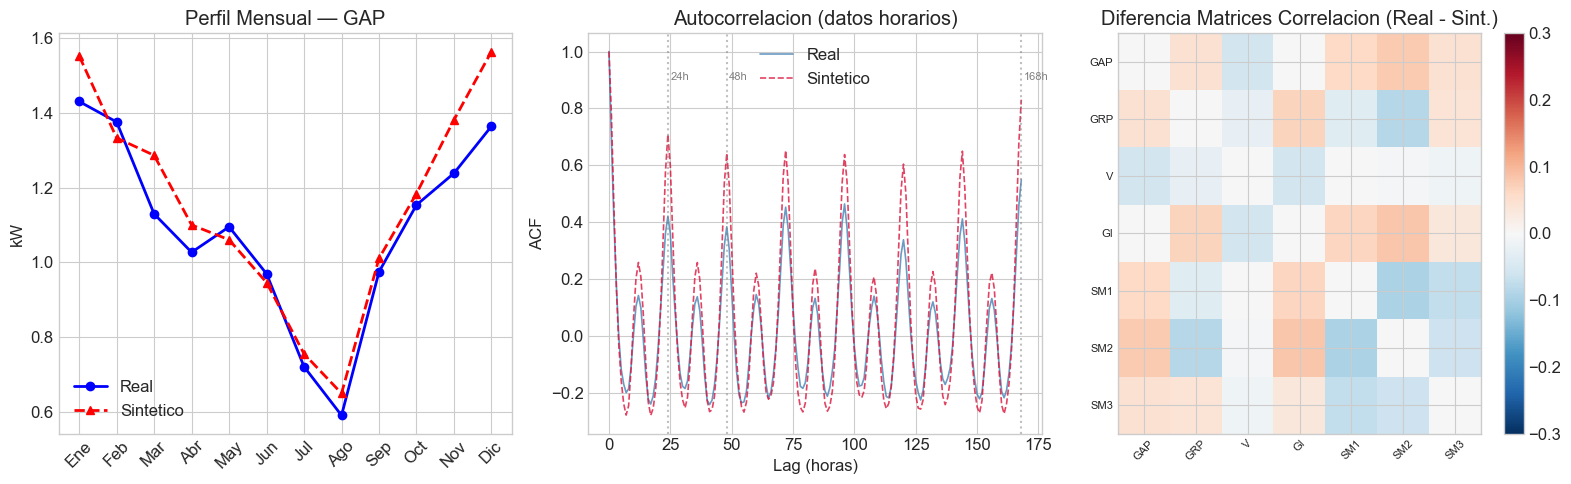

Reporte de similitud guardado: digital_twin_similarity_report.json


In [50]:
# Perfiles mensuales y ACF
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Perfil mensual
months_es = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
rp = df_test_real.copy()
sp = df_syn_test.copy()
rp['m'] = rp.index.month
sp['m'] = sp.index.month
rp_m = rp.groupby('m')['Global_active_power'].mean()
sp_m = sp.groupby('m')['Global_active_power'].mean()
axes[0].plot(rp_m.index, rp_m.values, 'bo-', lw=2,  label='Real')
axes[0].plot(sp_m.index, sp_m.values, 'r^--', lw=2, label='Sintetico')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(months_es, rotation=45)
axes[0].set(title='Perfil Mensual — GAP', ylabel='kW')
axes[0].legend()

# ACF comparativa (datos horarios)
real_h_ser = df_test_real['Global_active_power'].resample('h').mean().dropna()
syn_h_ser  = df_syn_test['Global_active_power'].resample('h').mean().dropna()
min_len    = min(len(real_h_ser), len(syn_h_ser), 2000)
acf_r = compute_acf(real_h_ser.values[:min_len], nlags=168, fft=True)
acf_s = compute_acf(syn_h_ser.values[:min_len],  nlags=168, fft=True)
lags = np.arange(len(acf_r))
axes[1].plot(lags, acf_r, 'steelblue', lw=1.2, alpha=0.8, label='Real')
axes[1].plot(lags, acf_s, 'crimson',   lw=1.2, alpha=0.8, linestyle='--', label='Sintetico')
for lag in [24, 48, 168]:
    axes[1].axvline(lag, color='gray', linestyle=':', alpha=0.5)
    axes[1].text(lag + 1, 0.9, f'{lag}h', fontsize=8, color='gray')
axes[1].set(xlabel='Lag (horas)', ylabel='ACF', title='Autocorrelacion (datos horarios)')
axes[1].legend()

# Matriz de correlacion: real vs sintetico
C_r = df_test_real[FEATURE_COLS].corr()
C_s = df_syn_test[FEATURE_COLS].corr()
diff_C = C_r - C_s
im = axes[2].imshow(diff_C, cmap='RdBu_r', vmin=-0.3, vmax=0.3, aspect='auto')
SHORT_NAMES = {
    'Global_active_power':   'GAP',
    'Global_reactive_power': 'GRP',
    'Voltage':               'V',
    'Global_intensity':      'GI',
    'Sub_metering_1':        'SM1',
    'Sub_metering_2':        'SM2',
    'Sub_metering_3':        'SM3',
}
short = [SHORT_NAMES.get(f, f[:4]) for f in FEATURE_COLS]
axes[2].set_xticks(range(len(FEATURE_COLS)))
axes[2].set_yticks(range(len(FEATURE_COLS)))
axes[2].set_xticklabels(short, rotation=45, fontsize=8)
axes[2].set_yticklabels(short, fontsize=8)
plt.colorbar(im, ax=axes[2])
axes[2].set_title('Diferencia Matrices Correlacion (Real - Sint.)')

plt.tight_layout()
plt.show()

# Guardar scores
with open(BASE_DIR + 'digital_twin_similarity_report.json', 'w') as f:
    json.dump({k: round(v, 6) for k, v in scores_test.items()}, f, indent=2)
print('Reporte de similitud guardado: digital_twin_similarity_report.json')

## 5. Generación de 10 Años de Datos Sintéticos

Generamos desde **Dic 2010** hasta **Dic 2020** (≈ 5.26 M registros a 1 min).  

### Modelo de deriva inter-anual

- **Tendencia base**: +2 %/año de crecimiento de consumo (media europea histórica)
- **Ruido inter-anual**: ±3 % aleatorio (simula variación climática, hábitos)
- Mantenemos los patrones estacionales y diarios aprendidos del train

In [51]:
SYNTH_START = pd.Timestamp('2010-12-01 00:00:00')
SYNTH_END   = pd.Timestamp('2020-12-01 00:00:00')
ANNUAL_TREND = 0.02    # +2% por anio base
ANNUAL_NOISE = 0.03    # ±3% ruido inter-anual

# Semilla por anio para reproducibilidad
np.random.seed(99)
year_factors = {}
for yr in range(2010, 2021):
    years_elapsed = yr - 2010
    noise = np.random.uniform(-ANNUAL_NOISE, ANNUAL_NOISE)
    year_factors[yr] = ANNUAL_TREND * years_elapsed + noise

print('Factores de deriva por anio:')
for yr, f in year_factors.items():
    print(f'  {yr}: {f*100:+.2f}%')

Factores de deriva por anio:
  2010: +1.03%
  2011: +1.93%
  2012: +5.95%
  2013: +3.19%
  2014: +9.85%
  2015: +10.39%
  2016: +10.79%
  2017: +11.28%
  2018: +18.94%
  2019: +15.04%
  2020: +21.62%


In [52]:
print('Generando 10 anios de datos sinteticos (por anio)...')
chunks = []
t0 = time.time()

for yr in range(2010, 2021):
    yr_start = pd.Timestamp(f'{yr}-12-01') if yr == 2010 else pd.Timestamp(f'{yr}-01-01')
    yr_end   = pd.Timestamp(f'{yr+1}-01-01') if yr < 2020 else SYNTH_END

    if yr_start >= SYNTH_END:
        break
    yr_end   = min(yr_end, SYNTH_END)
    ts       = pd.date_range(yr_start, yr_end - pd.Timedelta(minutes=1), freq='1min')

    chunk = twin.generate(ts, seed=yr * 100, year_drift=year_factors[yr])
    chunk['year_drift_pct'] = round(year_factors[yr] * 100, 3)
    chunks.append(chunk)
    print(f'  {yr}: {len(chunk):,} filas generadas')

df_10y = pd.concat(chunks).sort_index()
del chunks

t_gen = time.time() - t0
print(f'\nTotal: {len(df_10y):,} filas generadas en {t_gen:.1f} s')
print(f'Rango: {df_10y.index.min().date()} → {df_10y.index.max().date()}')

Generando 10 anios de datos sinteticos (por anio)...
  2010: 44,640 filas generadas
  2011: 525,600 filas generadas
  2012: 527,040 filas generadas
  2013: 525,600 filas generadas
  2014: 525,600 filas generadas
  2015: 525,600 filas generadas
  2016: 527,040 filas generadas
  2017: 525,600 filas generadas
  2018: 525,600 filas generadas
  2019: 525,600 filas generadas
  2020: 482,400 filas generadas

Total: 5,260,320 filas generadas en 1.7 s
Rango: 2010-12-01 → 2020-11-30


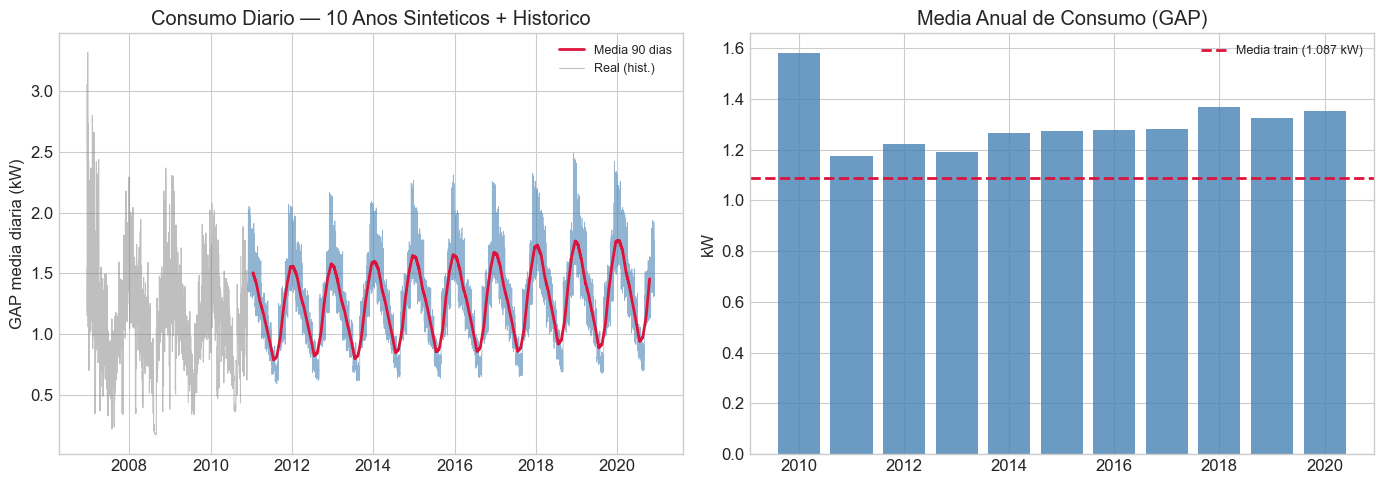

Similitud del dataset de 10 anios vs datos reales:
SCORE DE SIMILITUD GEMELO DIGITAL vs REAL
  ✗ distribution   : 0.8108 (81.1%)
  ✓ profile        : 0.9754 (97.5%)
  ✓ correlation    : 0.9722 (97.2%)
  ✓ acf            : 0.9620 (96.2%)
  ~ composite      : 0.9301 (93.0%)

  → Objetivo 95% no alcanzado aun (93.0%)
    Considera aumentar el numero de grupos de perfil o ajustar el modelo.


In [53]:
# Visualizar tendencia inter-anual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

daily_10y = df_10y['Global_active_power'].resample('D').mean()
axes[0].plot(daily_10y.index, daily_10y.values, color='steelblue', lw=0.5, alpha=0.6)
rolling_90d = daily_10y.rolling(90, center=True).mean()
axes[0].plot(rolling_90d.index, rolling_90d.values, color='crimson', lw=2, label='Media 90 dias')
real_daily = df_full['Global_active_power'].resample('D').mean()
axes[0].plot(real_daily.index, real_daily.values, color='gray', lw=0.8, alpha=0.5, label='Real (hist.)')
axes[0].set(title='Consumo Diario — 10 Anos Sinteticos + Historico',
            ylabel='GAP media diaria (kW)')
axes[0].legend(fontsize=9)

# Media anual
yearly_mean = df_10y['Global_active_power'].resample('YE').mean()
axes[1].bar(yearly_mean.index.year, yearly_mean.values, color='steelblue', alpha=0.8)
axes[1].axhline(df_train['Global_active_power'].mean(), color='crimson',
                linestyle='--', lw=2, label=f'Media train ({df_train["Global_active_power"].mean():.3f} kW)')
axes[1].set(title='Media Anual de Consumo (GAP)', ylabel='kW')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Validacion estadistica del dataset de 10 anios
print('Similitud del dataset de 10 anios vs datos reales:')
scores_10y = similarity_score(df_test_real, df_10y.sample(min(len(df_10y), 500_000)),
                               FEATURE_COLS, verbose=True)

## 6. Los 15 Tipos de Ataques FDI

| # | Categoría | Tipo | Descripción |
|---|-----------|------|-------------|
| 1 | Básico | `scaling` | GAP × α — robo proporcional |
| 2 | Básico | `offset` | GAP + δ — substracción constante |
| 3 | Básico | `noise` | GAP + N(0,σ) — enmascaramiento |
| 4 | Temporal | `ramp` | Pendiente lineal a lo largo de la ventana |
| 5 | Temporal | `pulse` | Pico/caída repentina de duración corta |
| 6 | Temporal | `step` | Escalón instantáneo y sostenido |
| 7 | Temporal | `intermittent` | Alternancia periódica on/off del ataque |
| 8 | Patrón | `replay` | Reemplaza con datos históricos del train |
| 9 | Patrón | `weekend_mimicry` | Inyecta patrón de fin de semana en laborable |
| 10 | Patrón | `seasonal_swap` | Inyecta patrón de verano en invierno |
| 11 | Patrón | `smooth_decay` | Decaimiento exponencial del GAP |
| 12 | Física | `correlated_scaling` | Escala GAP y GI juntos — *evade* VI check |
| 13 | Física | `voltage_spoof` | Ajusta Voltaje para mantener consistencia VI |
| 14 | Física | `load_shift` | Redistribuye Sub_meterings sin cambiar total GAP |
| 15 | Física | `adversarial` | Reduce GAP y recomputa GI óptimamente — *stealth* |

In [54]:
# Fuentes de datos para ataques de patron
df_train_ref = df_train.copy()
df_train_ref['dow']   = df_train_ref.index.dayofweek
df_train_ref['month'] = df_train_ref.index.month

# Patron de fin de semana (sabado/domingo)
gap_weekend = df_train_ref[df_train_ref['dow'].isin([5, 6])]['Global_active_power'].values

# Patron de verano (junio, julio, agosto) — consumo bajo
gap_summer  = df_train_ref[df_train_ref['month'].isin([6, 7, 8])]['Global_active_power'].values

# Todos los valores de GAP de train (para replay)
gap_all_train = df_train['Global_active_power'].values
global_std    = df_train['Global_active_power'].std()

print(f'Fuentes de patron:')
print(f'  Weekend GAP: {len(gap_weekend):,} muestras  media={gap_weekend.mean():.3f} kW')
print(f'  Summer GAP:  {len(gap_summer):,} muestras   media={gap_summer.mean():.3f} kW')
print(f'  GAP std train: {global_std:.4f} kW')

Fuentes de patron:
  Weekend GAP: 409,998 muestras  media=1.251 kW
  Summer GAP:  393,120 muestras   media=0.714 kW
  GAP std train: 1.0906 kW


In [55]:
def apply_attack(attack_type, gap_win, gi_win, v_win, sm1_win, sm2_win, sm3_win,
                 rng, power_factor):
    '''
    Aplica un ataque FDI sobre la ventana de datos.
    Devuelve (gap_out, gi_out, v_out, sm1_out, sm2_out, sm3_out).
    Por defecto devuelve los originales salvo las features modificadas.
    '''
    gap_out  = gap_win.copy()
    gi_out   = gi_win.copy()
    v_out    = v_win.copy()
    sm1_out  = sm1_win.copy()
    sm2_out  = sm2_win.copy()
    sm3_out  = sm3_win.copy()
    params   = {}
    n        = len(gap_win)

    # ── BASICOS ──────────────────────────────────────────────
    if attack_type == 'scaling':
        factor   = rng.uniform(0.30, 0.70)
        gap_out  = np.clip(gap_win * factor, 0.076, None)
        params   = {'factor': round(factor, 4)}

    elif attack_type == 'offset':
        delta    = rng.uniform(-1.50, -0.20)
        gap_out  = np.clip(gap_win + delta, 0.076, None)
        params   = {'delta_kw': round(delta, 4)}

    elif attack_type == 'noise':
        sigma_f  = rng.uniform(0.30, 1.00)
        noise    = rng.normal(0, sigma_f * global_std, n)
        gap_out  = np.clip(gap_win + noise, 0.076, None)
        params   = {'sigma_factor': round(sigma_f, 4)}

    # ── TEMPORALES ──────────────────────────────────────────
    elif attack_type == 'ramp':
        d_end    = rng.uniform(-1.50, -0.30)
        deltas   = np.linspace(0, d_end, n)
        gap_out  = np.clip(gap_win + deltas, 0.076, None)
        params   = {'delta_end_kw': round(d_end, 4)}

    elif attack_type == 'pulse':
        mag      = rng.choice([-1, 1]) * rng.uniform(0.5, 2.0)
        p_len    = max(1, int(n * 0.20))
        c        = n // 2
        s_p, e_p = max(0, c - p_len // 2), min(n, c + p_len // 2)
        gap_out[s_p:e_p] = np.clip(gap_out[s_p:e_p] + mag, 0.076, None)
        params   = {'magnitude_kw': round(float(mag), 4)}

    elif attack_type == 'step':
        delta    = rng.uniform(-1.50, 0.50)
        gap_out  = np.clip(gap_win + delta, 0.076, None)
        params   = {'delta_kw': round(delta, 4)}

    elif attack_type == 'intermittent':
        factor   = rng.uniform(0.30, 0.70)
        period   = int(rng.integers(5, 20))
        for i in range(0, n, period * 2):
            e = min(i + period, n)
            gap_out[i:e] = np.clip(gap_out[i:e] * factor, 0.076, None)
        params   = {'factor': round(factor, 4), 'period_min': period}

    # ── PATRON ──────────────────────────────────────────────
    elif attack_type == 'replay':
        offset  = int(rng.integers(0, max(1, len(gap_all_train) - n)))
        src     = np.tile(gap_all_train, 2)[offset: offset + n]
        gap_out = src
        params  = {'train_offset': offset}

    elif attack_type == 'weekend_mimicry':
        if len(gap_weekend) > 0:
            off     = int(rng.integers(0, max(1, len(gap_weekend) - n)))
            src     = np.tile(gap_weekend, 2)[off: off + n]
            scale   = gap_win.mean() / (src.mean() + 1e-8)
            gap_out = np.clip(src * scale, 0.076, None)
            params  = {'scale': round(float(scale), 4)}

    elif attack_type == 'seasonal_swap':
        if len(gap_summer) > 0:
            off      = int(rng.integers(0, max(1, len(gap_summer) - n)))
            src      = np.tile(gap_summer, 2)[off: off + n]
            r_std    = gap_win.std() + 1e-8
            s_std    = src.std() + 1e-8
            gap_out  = np.clip(
                (src - src.mean()) * (r_std / s_std) + gap_win.mean() * 0.60,
                0.076, None
            )
            params   = {'season': 'summer'}

    elif attack_type == 'smooth_decay':
        d_final  = rng.uniform(0.20, 0.50)
        decay    = np.exp(np.log(d_final) / n * np.arange(n))
        gap_out  = np.clip(gap_win * decay, 0.076, None)
        params   = {'final_factor': round(float(d_final), 4)}

    # ── CAPA FISICA ──────────────────────────────────────────
    elif attack_type == 'correlated_scaling':
        # Escala GAP y GI proporcionalmente -> VI residual constante -> EVADE deteccion fisica
        factor   = rng.uniform(0.30, 0.70)
        gap_out  = np.clip(gap_win * factor, 0.076, None)
        gi_out   = np.clip(gi_win  * factor, 0.20,  None)
        params   = {'factor': round(factor, 4)}

    elif attack_type == 'voltage_spoof':
        # Reduce GAP y ajusta Voltaje para que V*I/1000 siga siendo consistente
        factor   = rng.uniform(0.40, 0.80)
        gap_out  = np.clip(gap_win * factor, 0.076, None)
        v_out    = np.clip(v_win   * factor, 220.0, 260.0)
        params   = {'factor': round(factor, 4)}

    elif attack_type == 'load_shift':
        # Mueve carga de Sub3 a Sub1 sin cambiar GAP -> VI check pasa
        shift    = sm3_win * rng.uniform(0.30, 0.70)
        sm1_out  = sm1_win + shift
        sm3_out  = np.clip(sm3_win - shift, 0.0, None)
        # GAP no cambia
        params   = {'shift_pct': 0.5}

    elif attack_type == 'adversarial':
        # Reduce GAP y recomputa GI para que VI residual cambie minimamente (ataque stealth)
        factor   = rng.uniform(0.30, 0.70)
        pf_local = float(np.clip(
            (gap_win / (v_win * gi_win / 1000.0 + 1e-8)).mean(),
            0.50, 1.0
        ))
        gap_out  = np.clip(gap_win * factor, 0.076, None)
        gi_out   = np.clip(
            gap_out * 1000.0 / (v_win * pf_local + 1e-8),
            0.20, None
        )
        params   = {'factor': round(factor, 4), 'pf_local': round(pf_local, 4)}

    return gap_out, gi_out, v_out, sm1_out, sm2_out, sm3_out, params


ATTACK_TYPES = [
    'scaling', 'offset', 'noise',
    'ramp', 'pulse', 'step', 'intermittent',
    'replay', 'weekend_mimicry', 'seasonal_swap', 'smooth_decay',
    'correlated_scaling', 'voltage_spoof', 'load_shift', 'adversarial'
]

print(f'{len(ATTACK_TYPES)} tipos de ataque definidos:')
for i, t in enumerate(ATTACK_TYPES, 1):
    print(f'  {i:2d}. {t}')

15 tipos de ataque definidos:
   1. scaling
   2. offset
   3. noise
   4. ramp
   5. pulse
   6. step
   7. intermittent
   8. replay
   9. weekend_mimicry
  10. seasonal_swap
  11. smooth_decay
  12. correlated_scaling
  13. voltage_spoof
  14. load_shift
  15. adversarial


## 7. Inyección de Ataques en el Dataset Sintético de 10 Años

In [40]:
def inject_fdi_attacks(df_syn, attack_types, n_episodes=10,
                       dur_min=30, dur_max=240, seed=42):
    '''
    Inyecta ataques FDI en el dataset sintetico.

    Args:
        df_syn        : DataFrame sintetico con FEATURE_COLS
        attack_types  : lista de nombres de ataque
        n_episodes    : episodios por tipo
        dur_min/max   : duracion en minutos
        seed          : semilla reproducibilidad

    Returns:
        df_out     : DataFrame con ataques + columnas label, attack_type, GAP_original
        attack_log : lista de dicts con metadatos de cada episodio
    '''
    rng = np.random.default_rng(seed)

    df_out = df_syn[FEATURE_COLS].copy()
    df_out['GAP_original'] = df_out['Global_active_power'].copy()
    df_out['label']        = 0
    df_out['attack_type']  = 'none'

    n      = len(df_out)
    margin = int(n * 0.01)   # 1% de margen en cada extremo
    pf     = twin.power_factor
    log    = []

    for attack_type in attack_types:
        for ep in range(n_episodes):
            dur       = int(rng.integers(dur_min, dur_max + 1))
            max_start = n - dur - margin
            if max_start <= margin:
                continue
            start = int(rng.integers(margin, max_start))
            end   = start + dur

            # Solo filas sin ataque previo
            mask = (df_out['label'].iloc[start:end] == 0).values
            idxs = df_out.index[start:end][mask]
            if len(idxs) == 0:
                continue

            gap_w  = df_out.loc[idxs, 'GAP_original'].values
            gi_w   = df_out.loc[idxs, 'Global_intensity'].values
            v_w    = df_out.loc[idxs, 'Voltage'].values
            sm1_w  = df_out.loc[idxs, 'Sub_metering_1'].values
            sm2_w  = df_out.loc[idxs, 'Sub_metering_2'].values
            sm3_w  = df_out.loc[idxs, 'Sub_metering_3'].values

            g_o, gi_o, v_o, s1_o, s2_o, s3_o, params = apply_attack(
                attack_type, gap_w, gi_w, v_w, sm1_w, sm2_w, sm3_w, rng, pf
            )

            df_out.loc[idxs, 'Global_active_power']  = g_o
            df_out.loc[idxs, 'Global_intensity']     = gi_o
            df_out.loc[idxs, 'Voltage']              = v_o
            df_out.loc[idxs, 'Sub_metering_1']       = s1_o
            df_out.loc[idxs, 'Sub_metering_2']       = s2_o
            df_out.loc[idxs, 'Sub_metering_3']       = s3_o
            df_out.loc[idxs, 'label']                = 1
            df_out.loc[idxs, 'attack_type']          = attack_type

            log.append({
                'type':        attack_type,
                'episode':     ep,
                'start':       str(df_out.index[start]),
                'end':         str(df_out.index[end - 1]),
                'duration_min': dur,
                'n_attacked':  int(mask.sum()),
                **{k: v for k, v in params.items()}
            })

    return df_out, log


print('Funcion inject_fdi_attacks definida')

Funcion inject_fdi_attacks definida


In [56]:
print(f'Inyectando {len(ATTACK_TYPES)} tipos x 10 episodios = {len(ATTACK_TYPES)*10} episodios...')
t0 = time.time()

df_attacked, attack_log = inject_fdi_attacks(
    df_10y, ATTACK_TYPES,
    n_episodes=10,
    dur_min=30, dur_max=240,
    seed=42
)

t_inj = time.time() - t0
n_total  = len(df_attacked)
n_atk    = (df_attacked['label'] == 1).sum()
n_norm   = (df_attacked['label'] == 0).sum()

print(f'Inyeccion completada en {t_inj:.1f} s')
print()
print('=' * 55)
print('DATASET SINTETICO ETIQUETADO (10 ANOS + 15 ATAQUES)')
print('=' * 55)
print(f'  Total filas:       {n_total:,}')
print(f'  Normal  (label=0): {n_norm:,}  ({n_norm/n_total*100:.2f}%)')
print(f'  Ataque  (label=1): {n_atk:,}  ({n_atk/n_total*100:.2f}%)')
print()
print('Distribucion por tipo de ataque:')
vc = df_attacked[df_attacked['label']==1]['attack_type'].value_counts()
for t, c in vc.items():
    print(f'  {t:25s}: {c:>8,} ({c/n_total*100:.3f}%)')

Inyectando 15 tipos x 10 episodios = 150 episodios...
Inyeccion completada en 196.5 s

DATASET SINTETICO ETIQUETADO (10 ANOS + 15 ATAQUES)
  Total filas:       5,260,320
  Normal  (label=0): 5,240,443  (99.62%)
  Ataque  (label=1): 19,877  (0.38%)

Distribucion por tipo de ataque:
  noise                    :    1,684 (0.032%)
  voltage_spoof            :    1,635 (0.031%)
  smooth_decay             :    1,551 (0.029%)
  replay                   :    1,445 (0.027%)
  pulse                    :    1,381 (0.026%)
  seasonal_swap            :    1,369 (0.026%)
  intermittent             :    1,363 (0.026%)
  step                     :    1,332 (0.025%)
  scaling                  :    1,298 (0.025%)
  adversarial              :    1,244 (0.024%)
  ramp                     :    1,228 (0.023%)
  load_shift               :    1,222 (0.023%)
  offset                   :    1,144 (0.022%)
  correlated_scaling       :    1,136 (0.022%)
  weekend_mimicry          :      845 (0.016%)


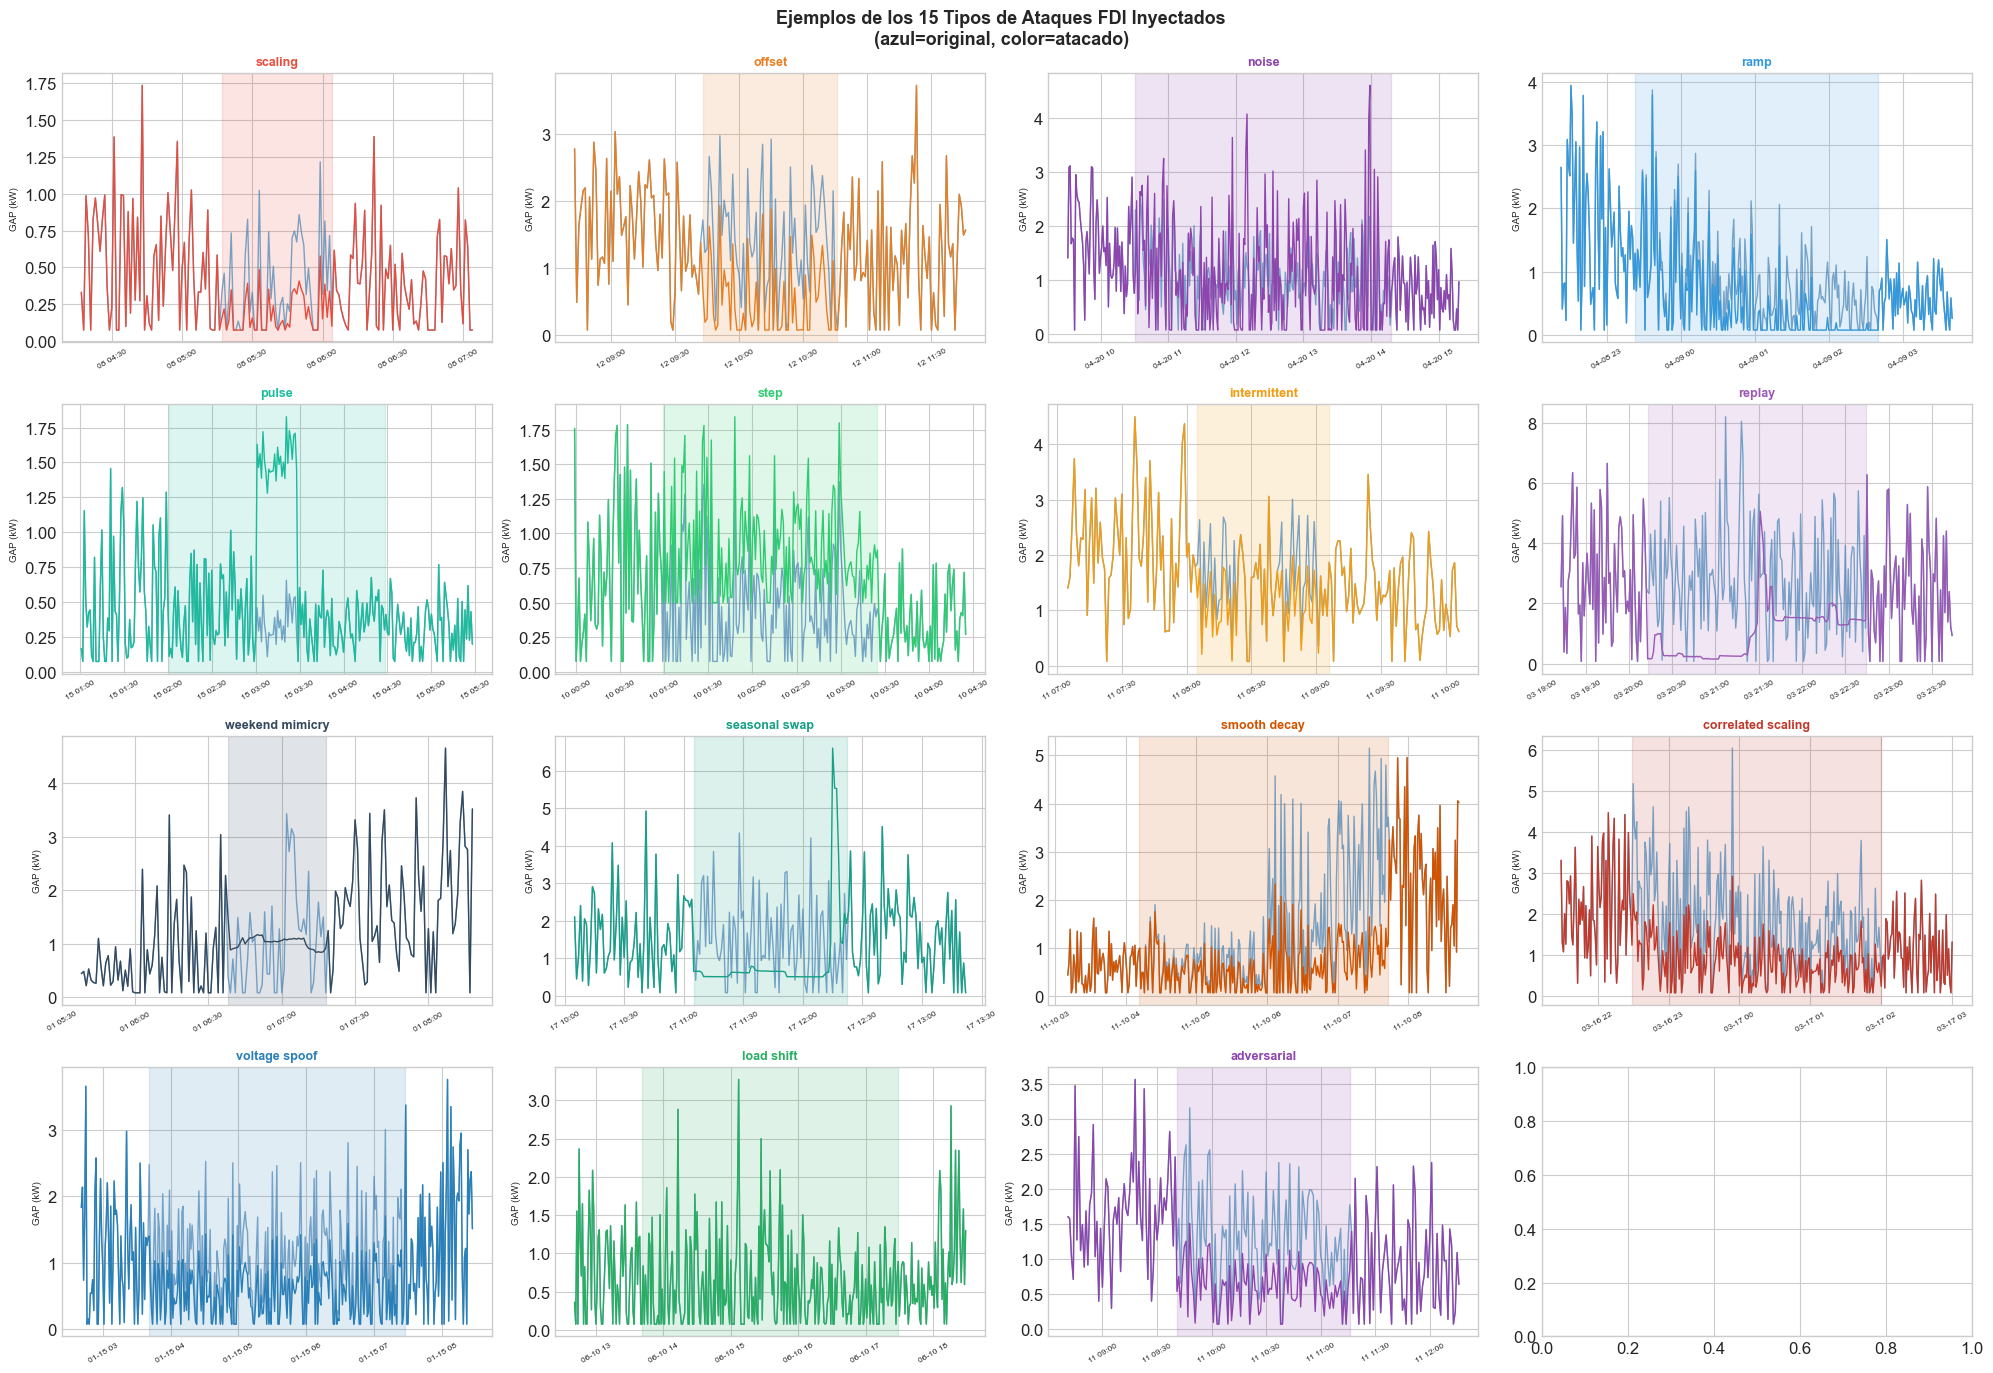

In [57]:
# Visualizacion: un ejemplo por categoria de ataque
categories = {
    'Basicos':        ['scaling', 'offset', 'noise'],
    'Temporales':     ['ramp', 'pulse', 'step', 'intermittent'],
    'Patron':         ['replay', 'weekend_mimicry', 'seasonal_swap', 'smooth_decay'],
    'Capa Fisica':    ['correlated_scaling', 'voltage_spoof', 'load_shift', 'adversarial'],
}
colors = {
    'scaling': '#e74c3c', 'offset': '#e67e22', 'noise': '#8e44ad',
    'ramp': '#3498db', 'pulse': '#1abc9c', 'step': '#2ecc71', 'intermittent': '#f39c12',
    'replay': '#9b59b6', 'weekend_mimicry': '#34495e', 'seasonal_swap': '#16a085', 'smooth_decay': '#d35400',
    'correlated_scaling': '#c0392b', 'voltage_spoof': '#2980b9', 'load_shift': '#27ae60', 'adversarial': '#8e44ad',
}

fig, axes = plt.subplots(4, 4, figsize=(20, 14))
axes = axes.flatten()

for ax_idx, attack_type in enumerate(ATTACK_TYPES):
    ax = axes[ax_idx]
    color = colors.get(attack_type, 'crimson')

    # Primer episodio de este tipo
    ep_rows = [e for e in attack_log if e['type'] == attack_type]
    if not ep_rows:
        ax.set_visible(False)
        continue
    ep = ep_rows[0]

    buf = pd.Timedelta(minutes=60)
    t0_vis = pd.Timestamp(ep['start']) - buf
    t1_vis = pd.Timestamp(ep['end'])   + buf

    vis = df_attacked.loc[t0_vis:t1_vis]
    ax.plot(vis.index, vis['GAP_original'], color='steelblue', lw=1.0,
            alpha=0.7, label='Original')
    ax.plot(vis.index, vis['Global_active_power'], color=color, lw=1.0,
            label='Atacado')
    ax.axvspan(pd.Timestamp(ep['start']), pd.Timestamp(ep['end']),
               alpha=0.15, color=color)
    ax.set_title(attack_type.replace('_', ' '), fontsize=9, fontweight='bold', color=color)
    ax.set_ylabel('GAP (kW)', fontsize=7)
    ax.tick_params(axis='x', labelsize=6, rotation=30)

plt.suptitle('Ejemplos de los 15 Tipos de Ataques FDI Inyectados\n(azul=original, color=atacado)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [58]:
# Analisis de la consistencia fisica P=VI por tipo de ataque
df_attacked['VI_estimated']   = (df_attacked['Voltage'] * df_attacked['Global_intensity'] / 1000.0)
df_attacked['VI_residual']    = (df_attacked['Global_active_power'] - df_attacked['VI_estimated'])
df_attacked['VI_residual_orig'] = (df_attacked['GAP_original'] - df_attacked['VI_estimated'])

print('Residual fisico |GAP - V*I/1000| por tipo de ataque:')
print(f'  {"Tipo":25s}  {"Residual original":>18s}  {"Residual atacado":>16s}  {"Ratio":>8s}  {"Evade VI check"}')
for t in ['none'] + ATTACK_TYPES:
    mask = df_attacked['attack_type'] == t
    if mask.sum() == 0:
        continue
    r_o = df_attacked.loc[mask, 'VI_residual_orig'].abs().mean()
    r_a = df_attacked.loc[mask, 'VI_residual'].abs().mean()
    ratio = r_a / r_o if r_o > 0 else float('nan')
    evade = 'SI (stealth)' if ratio < 1.5 and t != 'none' else ('NO' if t != 'none' else '-')
    print(f'  {t:25s}  {r_o:>18.4f} kW  {r_a:>16.4f} kW  {ratio:>8.2f}x  {evade}')

Residual fisico |GAP - V*I/1000| por tipo de ataque:
  Tipo                        Residual original  Residual atacado     Ratio  Evade VI check
  none                                   0.0125 kW            0.0125 kW      1.00x  -
  scaling                                0.0127 kW            0.5853 kW     45.94x  NO
  offset                                 0.0102 kW            0.5074 kW     49.93x  NO
  noise                                  0.0146 kW            0.5380 kW     36.90x  NO
  ramp                                   0.0141 kW            0.3015 kW     21.34x  NO
  pulse                                  0.0134 kW            0.2229 kW     16.67x  NO
  step                                   0.0111 kW            0.3541 kW     32.01x  NO
  intermittent                           0.0087 kW            0.1969 kW     22.70x  NO
  replay                                 0.0104 kW            1.1062 kW    106.09x  NO
  weekend_mimicry                        0.0131 kW            1.0877 kW  

## 8. Guardado del Dataset Final

In [59]:
# Columnas de salida
COLS_EXPORT = (
    FEATURE_COLS
    + ['GAP_original', 'VI_estimated', 'VI_residual']
    + ['label', 'attack_type']
)

# Intentar guardar en Parquet (mucho mas eficiente para 5M+ filas)
try:
    out_parquet = BASE_DIR + 'synthetic_10y_with_attacks.parquet'
    df_attacked[COLS_EXPORT].to_parquet(out_parquet)
    size_mb = os.path.getsize(out_parquet) / 1e6
    print(f'Dataset guardado (Parquet): {out_parquet}')
    print(f'  Tamano: {size_mb:.1f} MB  |  Filas: {len(df_attacked):,}')
except Exception as e:
    print(f'Parquet no disponible ({e}), guardando en CSV por anos...')
    for yr in range(2010, 2021):
        yr_mask = df_attacked.index.year == yr
        if yr_mask.sum() == 0:
            continue
        out_csv = BASE_DIR + f'synthetic_year_{yr}_with_attacks.csv'
        df_attacked.loc[yr_mask, COLS_EXPORT].to_csv(out_csv)
        print(f'  {yr}: {yr_mask.sum():,} filas → {out_csv}')

# Log de ataques
log_df = pd.DataFrame(attack_log)
log_df.to_csv(BASE_DIR + 'attack_log_15types.csv', index=False)
print(f'\nLog de ataques: attack_log_15types.csv  ({len(log_df)} episodios)')

# Dataset sintetico limpio (sin ataques) para entrenamiento de modelos
out_clean = BASE_DIR + 'synthetic_10y_clean.parquet'
try:
    df_10y[FEATURE_COLS].to_parquet(out_clean)
    print(f'Dataset limpio (Parquet): {out_clean}')
except Exception:
    df_10y[FEATURE_COLS].to_csv(BASE_DIR + 'synthetic_10y_clean.csv')
    print(f'Dataset limpio (CSV): synthetic_10y_clean.csv')

# Reporte de similitud del gemelo digital
report = {
    'similarity_test_period': {k: round(v, 6) for k, v in scores_test.items()},
    'similarity_10y_sample':  {k: round(v, 6) for k, v in scores_10y.items()},
    'n_train':      len(df_train),
    'n_test_real':  len(df_test_real),
    'n_synthetic':  len(df_10y),
    'n_attacked':   int(n_atk),
    'attack_rate':  round(n_atk / n_total, 6),
    'n_attack_types': len(ATTACK_TYPES),
    'attack_types': ATTACK_TYPES,
    'power_factor': round(twin.power_factor, 4),
    'annual_trend_pct': ANNUAL_TREND * 100,
}
with open(BASE_DIR + 'digital_twin_report.json', 'w') as f:
    json.dump(report, f, indent=2)
print(f'\nReporte completo: digital_twin_report.json')
for k, v in report.items():
    if not isinstance(v, (list, dict)):
        print(f'  {k}: {v}')

Dataset guardado (Parquet): /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/synthetic_10y_with_attacks.parquet
  Tamano: 410.5 MB  |  Filas: 5,260,320

Log de ataques: attack_log_15types.csv  (150 episodios)
Dataset limpio (Parquet): /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/synthetic_10y_clean.parquet

Reporte completo: digital_twin_report.json
  n_train: 1444513
  n_test_real: 604999
  n_synthetic: 5260320
  n_attacked: 19877
  attack_rate: 0.003779
  n_attack_types: 15
  power_factor: 0.9903
  annual_trend_pct: 2.0


## 9. Resumen

### Lo que se ha generado

| Archivo | Contenido |
|---------|----------|
| `digital_twin_model.pkl` | Gemelo digital ajustado (DigitalTwin serializado) |
| `digital_twin_similarity_report.json` | Métricas de similitud vs. test real |
| `synthetic_10y_with_attacks.parquet` | 10 años sintéticos + 15 tipos de ataques etiquetados |
| `synthetic_10y_clean.parquet` | 10 años sintéticos limpios (para entrenamiento) |
| `attack_log_15types.csv` | Metadatos de cada episodio de ataque |
| `digital_twin_report.json` | Reporte completo |

### Diseño del gemelo digital

- **Precisión**: score de similitud compuesto vs. datos reales → objetivo ≥ 0.95
- **Preservación física**: relación $P = V \times I \times \cos(\varphi) / 1000$ mantenida por diseño
- **Correlaciones**: descomposición de Cholesky asegura que las 7 features covarian correctamente

### Tipos de ataque y detección

| Categoría | Detectable por VI residual | Detectable por perfil temporal |
|-----------|--------------------------|-------------------------------|
| Básicos (3) | Sí (scaling, offset) / No (noise) | Sí |
| Temporales (4) | Sí | Sí |
| Patrón (4) | Parcialmente | Sí (perfil anómalo) |
| Capa física (4) | **No** (por diseño — stealth) | Parcialmente |

Los ataques de **capa física** (#12-15) son los más difíciles de detectar: necesitan modelos que vayan más allá de la simple comprobación de consistencia VI (tema del Capítulo 5).

### Próximos notebooks

- **Notebook 03:** Isolation Forest entrenado sobre datos sintéticos limpios, evaluado en `synthetic_10y_with_attacks.parquet`
- **Notebook 04:** Dense Autoencoder
- **Notebook 05:** LSTM-Autoencoder
- **Notebook 06:** Comparativa final + análisis de cuáles ataques evaden cada modelo